Confusion Matrix:
 [[30 43]
 [36 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.41      0.43        73
           1       0.49      0.53      0.51        77

    accuracy                           0.47       150
   macro avg       0.47      0.47      0.47       150
weighted avg       0.47      0.47      0.47       150



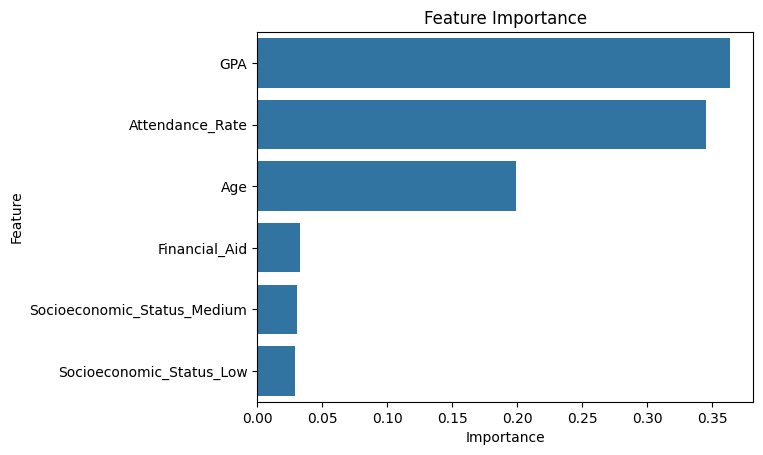


Results saved to 'student_enrollment_predictions.csv'


In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
data = pd.DataFrame({
    "Student_ID": np.arange(1, 501),  # Example IDs
    "GPA": np.random.uniform(2.0, 4.0, 500),
    "Attendance_Rate": np.random.uniform(50, 100, 500),
    "Socioeconomic_Status": np.random.choice(["Low", "Medium", "High"], 500),
    "Financial_Aid": np.random.choice([0, 1], 500),
    "Age": np.random.randint(18, 30, 500),
    "Enrolled": np.random.choice([0, 1], 500)  # Target variable
})


data = pd.get_dummies(data, columns=["Socioeconomic_Status"], drop_first=True)


scaler = StandardScaler()
numerical_features = ["GPA", "Attendance_Rate", "Age"]
data[numerical_features] = scaler.fit_transform(data[numerical_features])


X = data.drop(["Student_ID", "Enrolled"], axis=1)
y = data["Enrolled"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


feature_importances = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)
sns.barplot(x="Importance", y="Feature", data=feature_importances)
plt.title("Feature Importance")
plt.show()

data.drop(["Student_ID"], axis=1, inplace=True)

results = X_test.copy()
results["True_Label"] = y_test
results["Predicted_Label"] = y_pred
results.to_csv("student_enrollment_predictions.csv", index=False)
print("\nResults saved to 'student_enrollment_predictions.csv'")
